# Laboratorio 08 - Procesamiento de Imagenes con OpenCV

**Asignatura:** Computacion Grafica, Vision Computacional y Multimedia  
**Tema:** Procesamiento de imagenes  
**Autor:** Pacori Anccasi Diego Ivan

Este notebook resuelve los ejercicios propuestos de la guia de laboratorio 8. Como la carpeta del laboratorio no incluia imagenes ni notebooks base, se generan tres imagenes a color reproducibles: una persona, un gato y un perro. Luego se aplican las operaciones solicitadas con OpenCV, NumPy y Matplotlib.

## 0. Entorno usado

El entorno Conda utilizado se llama `lab08-cgvc` y fue registrado como kernel de Jupyter con el nombre visible `Python (lab08-cgvc)`.

Comandos principales usados:

```powershell
C:\Users\diego\anaconda3\Scripts\conda.exe create -y -n lab08-cgvc python=3.11 notebook ipykernel nbconvert numpy matplotlib opencv pillow
C:\Users\diego\anaconda3\Scripts\conda.exe run -n lab08-cgvc python -m ipykernel install --user --name lab08-cgvc --display-name "Python (lab08-cgvc)"
```

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

print("Python:", sys.version.split()[0])
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Pillow:", Image.__version__)

Python: 3.11.15
OpenCV: 4.13.0
NumPy: 2.4.6
Matplotlib: 3.11.0
Pillow: 12.2.0


In [2]:
ROOT = Path.cwd()
# Si el notebook se ejecuta desde la carpeta notebooks/, se sube al directorio del laboratorio.
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "resultados"
CAPTURES_DIR = ROOT / "capturas"

for directory in (DATA_DIR, RESULTS_DIR, CAPTURES_DIR):
    directory.mkdir(exist_ok=True)

print("Directorio del laboratorio:", ROOT)
print("Imagenes base:", DATA_DIR)
print("Resultados:", RESULTS_DIR)
print("Capturas:", CAPTURES_DIR)

Directorio del laboratorio: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC
Imagenes base: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\data
Resultados: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultados
Capturas: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\capturas


## 1. Creacion de imagenes base

La guia solicita escoger imagenes a color que contengan una persona o animal. Al no existir recursos de entrada en la carpeta, se crean tres imagenes sinteticas con diferentes tamanos. Esto hace que la solucion sea autocontenida y repetible en cualquier equipo.

persona: 720x520 px -> C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\data\persona.png
gato: 430x360 px -> C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\data\gato.png
perro: 560x390 px -> C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\data\perro.png


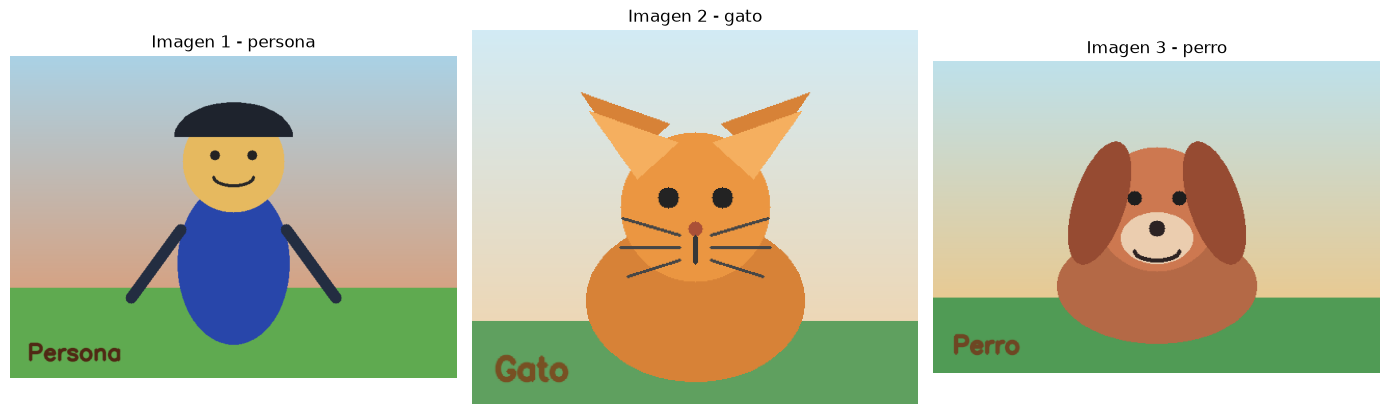

In [3]:
def gradient_background(height, width, top_bgr, bottom_bgr):
    top = np.array(top_bgr, dtype=np.float32)
    bottom = np.array(bottom_bgr, dtype=np.float32)
    alpha = np.linspace(0, 1, height, dtype=np.float32)[:, None, None]
    row = (1 - alpha) * top + alpha * bottom
    return np.repeat(row, width, axis=1).astype(np.uint8)


def draw_person_scene(width=720, height=520):
    img = gradient_background(height, width, (230, 210, 170), (95, 145, 230))
    cv2.rectangle(img, (0, int(height * 0.72)), (width, height), (80, 170, 95), -1)
    cx = width // 2
    # cuerpo y brazos
    cv2.ellipse(img, (cx, 335), (90, 130), 0, 0, 360, (170, 70, 40), -1)
    cv2.line(img, (cx - 85, 280), (cx - 165, 390), (65, 45, 35), 18)
    cv2.line(img, (cx + 85, 280), (cx + 165, 390), (65, 45, 35), 18)
    # rostro, cabello y detalles
    cv2.circle(img, (cx, 170), 82, (95, 185, 230), -1)
    cv2.ellipse(img, (cx, 130), (95, 55), 0, 180, 360, (45, 35, 30), -1)
    cv2.circle(img, (cx - 30, 160), 8, (35, 35, 35), -1)
    cv2.circle(img, (cx + 30, 160), 8, (35, 35, 35), -1)
    cv2.ellipse(img, (cx, 195), (32, 14), 0, 0, 180, (40, 40, 40), 4)
    cv2.putText(img, "Persona", (28, height - 30), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (20, 40, 80), 3, cv2.LINE_AA)
    return img


def draw_cat_scene(width=430, height=360):
    img = gradient_background(height, width, (245, 235, 210), (165, 210, 245))
    cv2.rectangle(img, (0, int(height * 0.78)), (width, height), (95, 160, 95), -1)
    cx, cy = width // 2, height // 2 + 15
    # cuerpo y cabeza
    cv2.ellipse(img, (cx, cy + 65), (105, 78), 0, 0, 360, (55, 130, 215), -1)
    cv2.circle(img, (cx, cy - 25), 72, (65, 150, 235), -1)
    # orejas
    pts1 = np.array([[cx - 64, cy - 70], [cx - 110, cy - 135], [cx - 25, cy - 105]], np.int32)
    pts2 = np.array([[cx + 64, cy - 70], [cx + 110, cy - 135], [cx + 25, cy - 105]], np.int32)
    cv2.fillConvexPoly(img, pts1, (55, 130, 215))
    cv2.fillConvexPoly(img, pts2, (55, 130, 215))
    cv2.fillConvexPoly(img, pts1 + np.array([8, 18]), (95, 175, 245))
    cv2.fillConvexPoly(img, pts2 + np.array([-8, 18]), (95, 175, 245))
    # rostro
    cv2.circle(img, (cx - 26, cy - 34), 10, (35, 35, 35), -1)
    cv2.circle(img, (cx + 26, cy - 34), 10, (35, 35, 35), -1)
    cv2.circle(img, (cx, cy - 4), 7, (55, 80, 170), -1)
    cv2.line(img, (cx, cy + 4), (cx, cy + 28), (55, 55, 55), 3)
    for side in (-1, 1):
        cv2.line(img, (cx + side * 15, cy + 2), (cx + side * 70, cy - 14), (70, 70, 70), 2)
        cv2.line(img, (cx + side * 15, cy + 14), (cx + side * 72, cy + 14), (70, 70, 70), 2)
        cv2.line(img, (cx + side * 15, cy + 26), (cx + side * 65, cy + 42), (70, 70, 70), 2)
    cv2.putText(img, "Gato", (22, height - 24), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (35, 80, 120), 3, cv2.LINE_AA)
    return img


def draw_dog_scene(width=560, height=390):
    img = gradient_background(height, width, (235, 225, 190), (120, 195, 245))
    cv2.rectangle(img, (0, int(height * 0.76)), (width, height), (85, 155, 80), -1)
    cx, cy = width // 2, height // 2 + 8
    # cuerpo, cabeza y orejas
    cv2.ellipse(img, (cx, cy + 78), (125, 72), 0, 0, 360, (70, 105, 180), -1)
    cv2.circle(img, (cx, cy - 18), 78, (80, 120, 205), -1)
    cv2.ellipse(img, (cx - 72, cy - 26), (32, 80), 18, 0, 360, (50, 75, 150), -1)
    cv2.ellipse(img, (cx + 72, cy - 26), (32, 80), -18, 0, 360, (50, 75, 150), -1)
    # hocico y rostro
    cv2.ellipse(img, (cx, cy + 18), (45, 32), 0, 0, 360, (175, 205, 235), -1)
    cv2.circle(img, (cx - 28, cy - 32), 9, (30, 30, 30), -1)
    cv2.circle(img, (cx + 28, cy - 32), 9, (30, 30, 30), -1)
    cv2.circle(img, (cx, cy + 6), 10, (35, 35, 45), -1)
    cv2.ellipse(img, (cx, cy + 34), (28, 12), 0, 0, 180, (35, 35, 45), 3)
    cv2.putText(img, "Perro", (24, height - 25), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (35, 70, 110), 3, cv2.LINE_AA)
    return img


def bgr_to_rgb(img):
    if img.ndim == 2:
        return img
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def show_images(items, cols=3, figsize=(14, 6), save_path=None):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, (title, image) in zip(axes, items):
        if image.ndim == 2:
            ax.imshow(image, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(bgr_to_rgb(image))
        ax.set_title(title)
        ax.axis("off")
    for ax in axes[len(items):]:
        ax.axis("off")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()

base_images = {
    "persona": draw_person_scene(),
    "gato": draw_cat_scene(),
    "perro": draw_dog_scene(),
}

base_paths = {}
for name, image in base_images.items():
    path = DATA_DIR / f"{name}.png"
    cv2.imwrite(str(path), image)
    base_paths[name] = path
    print(f"{name}: {image.shape[1]}x{image.shape[0]} px -> {path}")

show_images(
    [("Imagen 1 - persona", base_images["persona"]), ("Imagen 2 - gato", base_images["gato"]), ("Imagen 3 - perro", base_images["perro"])],
    save_path=CAPTURES_DIR / "00_imagenes_base.png",
)

## 2. Redimensionar imagenes sin deformarlas

Se identifica la imagen mas grande por area y se usa su tamano como objetivo. Las imagenes pequenas se escalan manteniendo su relacion de aspecto; los espacios restantes se rellenan con bordes negros. Esta tecnica se conoce como *letterbox*.

Imagen objetivo: persona 720x520
persona: escala=1.000, offset=(0, 0), salida=720x520
gato: escala=1.444, offset=(49, 0), salida=720x520
perro: escala=1.286, offset=(0, 9), salida=720x520


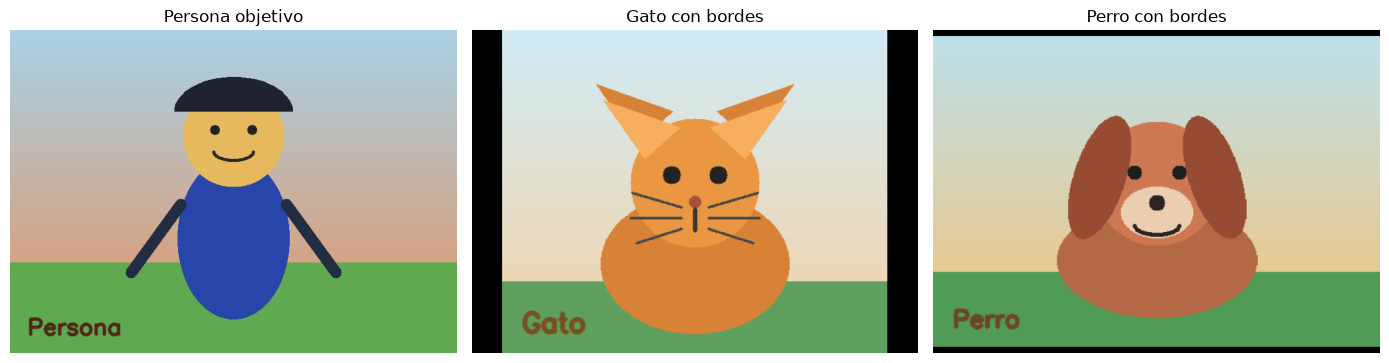

In [4]:
def resize_with_letterbox(image, target_width, target_height, border_color=(0, 0, 0)):
    h, w = image.shape[:2]
    scale = min(target_width / w, target_height / h)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.full((target_height, target_width, 3), border_color, dtype=np.uint8)
    x0 = (target_width - new_w) // 2
    y0 = (target_height - new_h) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas, scale, (x0, y0)

loaded = {name: cv2.imread(str(path)) for name, path in base_paths.items()}
areas = {name: img.shape[0] * img.shape[1] for name, img in loaded.items()}
target_name = max(areas, key=areas.get)
target_h, target_w = loaded[target_name].shape[:2]
print("Imagen objetivo:", target_name, f"{target_w}x{target_h}")

resized_images = {}
for name, image in loaded.items():
    resized, scale, offset = resize_with_letterbox(image, target_w, target_h)
    resized_images[name] = resized
    cv2.imwrite(str(RESULTS_DIR / f"01_{name}_redimensionada.png"), resized)
    print(f"{name}: escala={scale:.3f}, offset={offset}, salida={resized.shape[1]}x{resized.shape[0]}")

show_images(
    [("Persona objetivo", resized_images["persona"]), ("Gato con bordes", resized_images["gato"]), ("Perro con bordes", resized_images["perro"])],
    save_path=CAPTURES_DIR / "01_redimension_aspect_ratio.png",
)

## 3. Nueva imagen con canales de color combinados

OpenCV trabaja internamente con el orden BGR, no RGB. Por eso, para construir una imagen con el canal rojo de la primera imagen, verde de la segunda y azul de la tercera, se combinan como `B=perro`, `G=gato`, `R=persona`.

Imagen combinada guardada en: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultados\02_canales_combinados.png


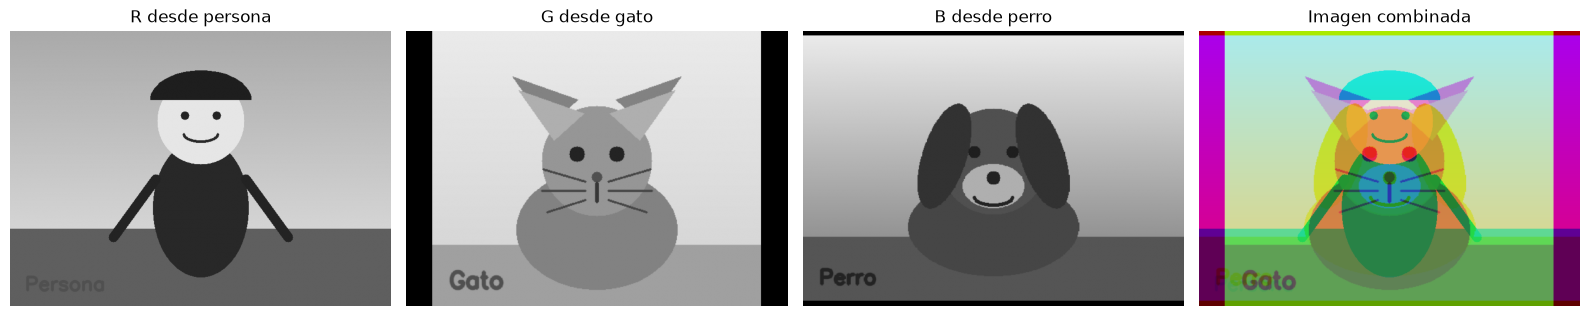

In [5]:
b_persona, g_persona, r_persona = cv2.split(resized_images["persona"])
b_gato, g_gato, r_gato = cv2.split(resized_images["gato"])
b_perro, g_perro, r_perro = cv2.split(resized_images["perro"])

combined = cv2.merge([b_perro, g_gato, r_persona])
combined_path = RESULTS_DIR / "02_canales_combinados.png"
cv2.imwrite(str(combined_path), combined)
print("Imagen combinada guardada en:", combined_path)

show_images(
    [
        ("R desde persona", r_persona),
        ("G desde gato", g_gato),
        ("B desde perro", b_perro),
        ("Imagen combinada", combined),
    ],
    cols=4,
    figsize=(16, 4),
    save_path=CAPTURES_DIR / "02_canales_combinados.png",
)

## 4. Conversion a negativo y escala de grises

El negativo se obtiene invirtiendo cada intensidad: `nuevo_valor = 255 - valor_original`. Para escala de grises se usa `cv2.cvtColor`, que pondera los canales y produce una sola matriz de intensidades.

Negativo: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultados\03_negativo.png
Escala de grises: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultados\03_negativo_grises.png


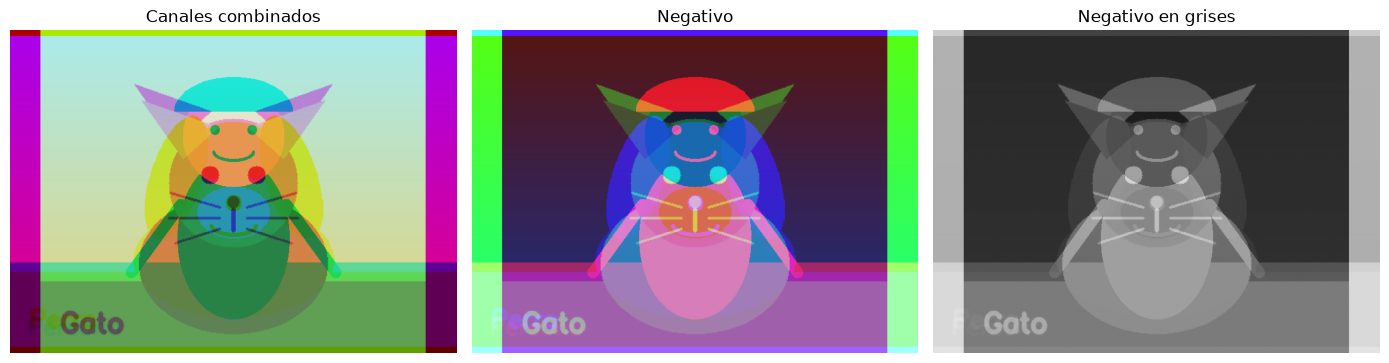

In [6]:
negative = cv2.bitwise_not(combined)
gray_negative = cv2.cvtColor(negative, cv2.COLOR_BGR2GRAY)

negative_path = RESULTS_DIR / "03_negativo.png"
gray_path = RESULTS_DIR / "03_negativo_grises.png"
cv2.imwrite(str(negative_path), negative)
cv2.imwrite(str(gray_path), gray_negative)

print("Negativo:", negative_path)
print("Escala de grises:", gray_path)

show_images(
    [("Canales combinados", combined), ("Negativo", negative), ("Negativo en grises", gray_negative)],
    cols=3,
    figsize=(14, 5),
    save_path=CAPTURES_DIR / "03_negativo_y_grises.png",
)

## 5. Aplicacion interactiva para visualizar canales

La guia pide una ventana donde el usuario pueda alternar canales rojo, verde y azul con teclas. En un notebook ejecutado automaticamente no conviene abrir ventanas bloqueantes, por eso se deja la funcion interactiva lista para ejecutar en PowerShell y se genera una simulacion visual de sus estados.

Funcion interactiva creada: channel_viewer_interactive(combined_path)
Teclas: r alterna rojo, g alterna verde, b alterna azul, q sale.


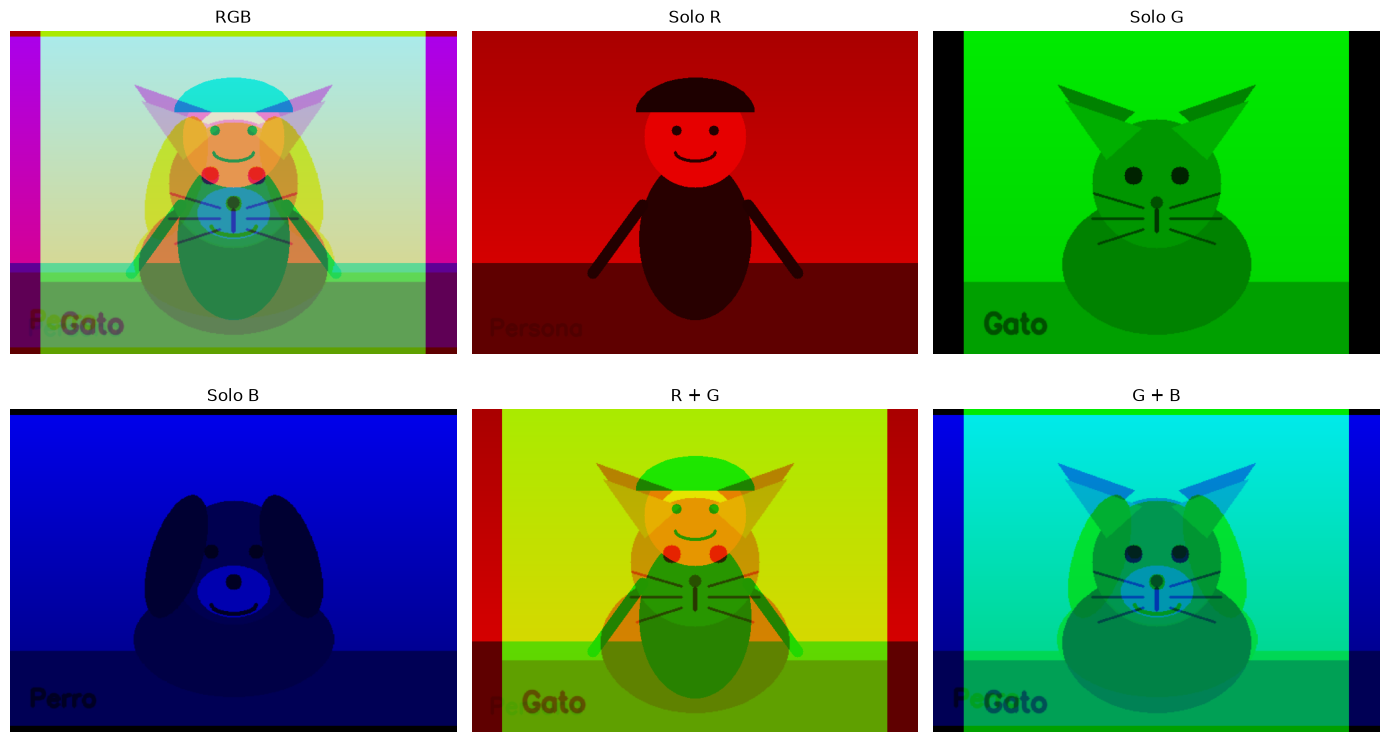

In [7]:
def filter_channels(image_bgr, show_red=True, show_green=True, show_blue=True):
    filtered = image_bgr.copy()
    if not show_blue:
        filtered[:, :, 0] = 0
    if not show_green:
        filtered[:, :, 1] = 0
    if not show_red:
        filtered[:, :, 2] = 0
    return filtered


def channel_viewer_interactive(image_path):
    # Ejecutar manualmente en PowerShell/Jupyter local: r, g, b alternan canales; q sale.
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(image_path)
    show_red = show_green = show_blue = True
    window = "Visor de canales - r/g/b alternan, q sale"
    cv2.namedWindow(window, cv2.WINDOW_NORMAL)
    while True:
        view = filter_channels(image, show_red, show_green, show_blue)
        status = f"R:{int(show_red)} G:{int(show_green)} B:{int(show_blue)}"
        cv2.putText(view, status, (24, 42), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 3, cv2.LINE_AA)
        cv2.imshow(window, view)
        key = cv2.waitKey(30) & 0xFF
        if key == ord("r"):
            show_red = not show_red
        elif key == ord("g"):
            show_green = not show_green
        elif key == ord("b"):
            show_blue = not show_blue
        elif key == ord("q") or key == 27:
            break
    cv2.destroyAllWindows()

channel_states = [
    ("RGB", True, True, True),
    ("Solo R", True, False, False),
    ("Solo G", False, True, False),
    ("Solo B", False, False, True),
    ("R + G", True, True, False),
    ("G + B", False, True, True),
]
state_images = [(title, filter_channels(combined, r, g, b)) for title, r, g, b in channel_states]
for title, img in state_images:
    cv2.imwrite(str(RESULTS_DIR / f"04_canales_{title.lower().replace(' ', '_').replace('+', 'mas')}.png"), img)

print("Funcion interactiva creada: channel_viewer_interactive(combined_path)")
print("Teclas: r alterna rojo, g alterna verde, b alterna azul, q sale.")

show_images(state_images, cols=3, figsize=(14, 8), save_path=CAPTURES_DIR / "04_visor_canales_simulado.png")

## 6. Dibujo de figuras y texto en una imagen

Se abre la imagen de la persona, se dibuja un circulo sobre el rostro y se agrega una etiqueta. Las funciones principales son `cv2.circle` para la figura y `cv2.putText` para el texto.

Imagen anotada: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultados\05_persona_anotada.png


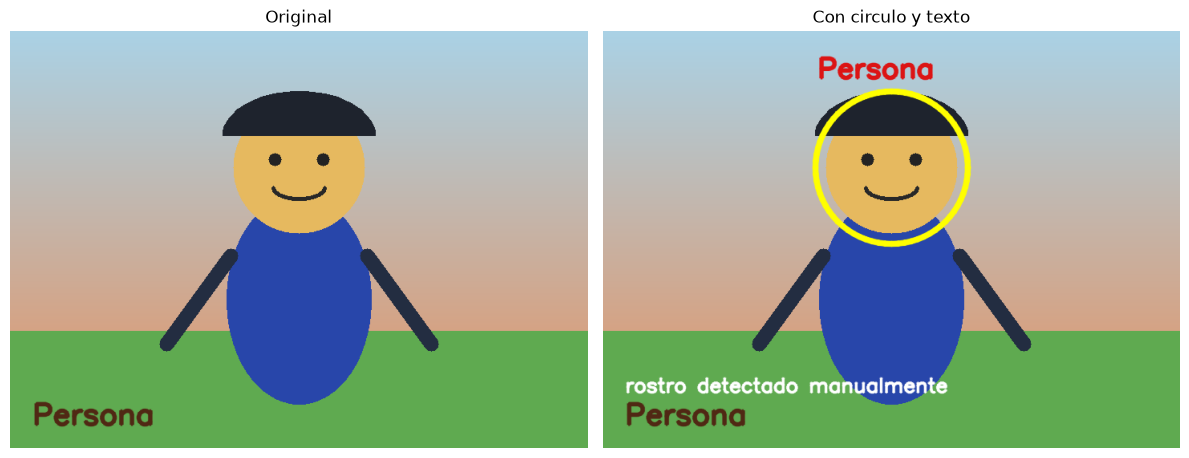

In [8]:
annotated = loaded["persona"].copy()
face_center = (annotated.shape[1] // 2, 170)
cv2.circle(annotated, face_center, 95, (0, 255, 255), 6, cv2.LINE_AA)
cv2.putText(annotated, "Persona", (face_center[0] - 92, face_center[1] - 112), cv2.FONT_HERSHEY_SIMPLEX, 1.15, (20, 20, 220), 3, cv2.LINE_AA)
cv2.putText(annotated, "rostro detectado manualmente", (28, annotated.shape[0] - 70), cv2.FONT_HERSHEY_SIMPLEX, 0.82, (255, 255, 255), 2, cv2.LINE_AA)

annotated_path = RESULTS_DIR / "05_persona_anotada.png"
cv2.imwrite(str(annotated_path), annotated)
print("Imagen anotada:", annotated_path)

show_images(
    [("Original", loaded["persona"]), ("Con circulo y texto", annotated)],
    cols=2,
    figsize=(12, 5),
    save_path=CAPTURES_DIR / "05_figuras_y_texto.png",
)

## 7. Aplicacion de umbral binario

El threshold binario separa pixeles en dos clases. Si la intensidad supera el umbral, el pixel se vuelve blanco; si no, se vuelve negro. Tambien se muestra el metodo de Otsu, que calcula automaticamente un umbral a partir del histograma.

Umbral fijo: 127 -> C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultados\06_threshold_binario_127.png
Umbral Otsu calculado: 151.0 -> C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultados\06_threshold_binario_otsu.png


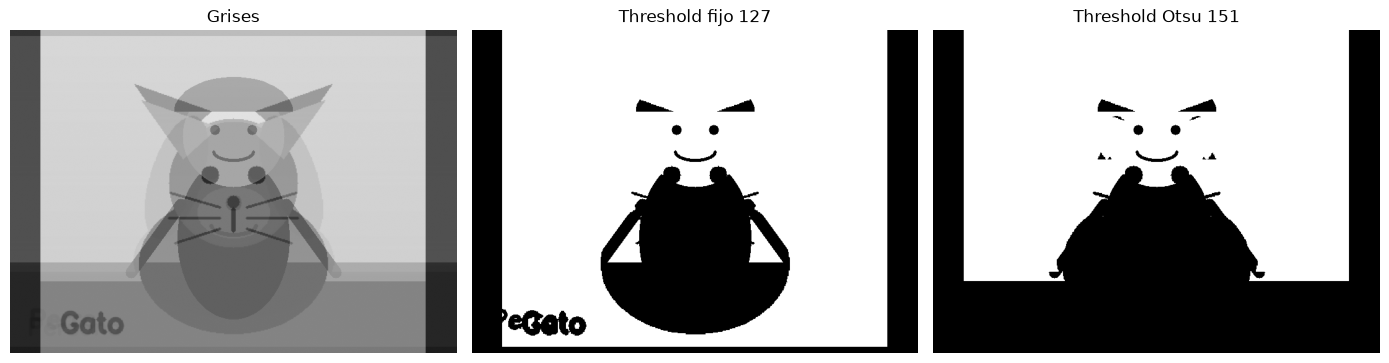

In [9]:
gray_for_threshold = cv2.cvtColor(combined, cv2.COLOR_BGR2GRAY)
fixed_threshold_value = 127
_, binary_fixed = cv2.threshold(gray_for_threshold, fixed_threshold_value, 255, cv2.THRESH_BINARY)
otsu_value, binary_otsu = cv2.threshold(gray_for_threshold, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fixed_path = RESULTS_DIR / "06_threshold_binario_127.png"
otsu_path = RESULTS_DIR / "06_threshold_binario_otsu.png"
cv2.imwrite(str(fixed_path), binary_fixed)
cv2.imwrite(str(otsu_path), binary_otsu)

print("Umbral fijo:", fixed_threshold_value, "->", fixed_path)
print("Umbral Otsu calculado:", round(float(otsu_value), 2), "->", otsu_path)

show_images(
    [("Grises", gray_for_threshold), ("Threshold fijo 127", binary_fixed), (f"Threshold Otsu {otsu_value:.0f}", binary_otsu)],
    cols=3,
    figsize=(14, 5),
    save_path=CAPTURES_DIR / "06_threshold_binario.png",
)

## 8. Programa de dibujo interactivo con mouse y teclado

Se implementa una aplicacion con eventos de mouse y teclado. Permite dibujar rectangulos, circulos y lineas; tambien deshacer y guardar. Igual que en el visor de canales, el bucle interactivo queda listo para ejecucion manual y el notebook genera una captura simulada del resultado final.

Clase interactiva lista: app = DrawingApp(); app.run()
Evidencia simulada guardada en: C:\Users\diego\OneDrive\Desktop\Laboratorio-08-CGVC\resultados\07_dibujo_interactivo_simulado.png


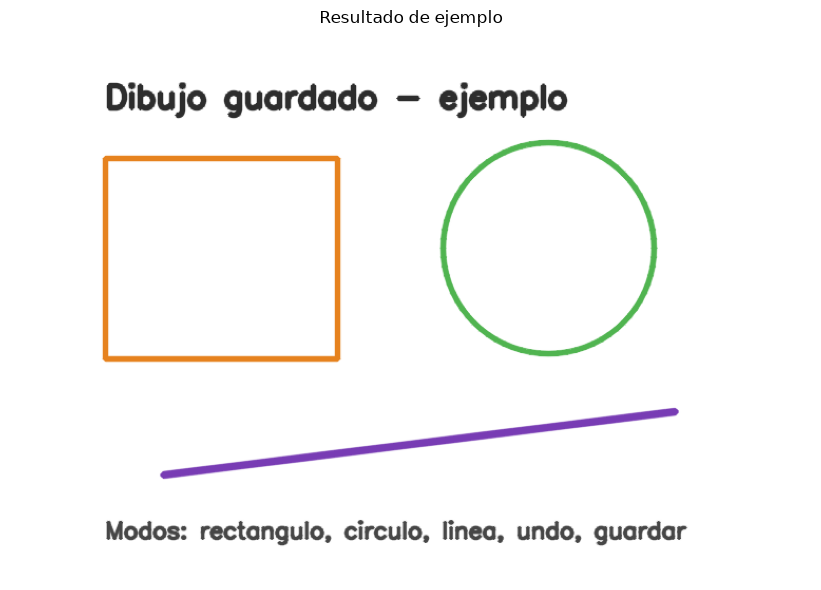

In [10]:
class DrawingApp:
    def __init__(self, width=900, height=620, save_path=RESULTS_DIR / "07_dibujo_interactivo.png"):
        self.canvas = np.full((height, width, 3), 255, dtype=np.uint8)
        self.mode = "rectangle"
        self.start = None
        self.history = []
        self.save_path = Path(save_path)
        self.window = "Dibujo interactivo - r/c/l modo, u deshacer, s guardar, q salir"

    def push_history(self):
        self.history.append(self.canvas.copy())
        if len(self.history) > 20:
            self.history.pop(0)

    def undo(self):
        if self.history:
            self.canvas = self.history.pop()

    def draw_shape(self, start, end):
        self.push_history()
        if self.mode == "rectangle":
            cv2.rectangle(self.canvas, start, end, (30, 130, 230), 3, cv2.LINE_AA)
        elif self.mode == "circle":
            radius = int(np.hypot(end[0] - start[0], end[1] - start[1]))
            cv2.circle(self.canvas, start, radius, (80, 180, 80), 3, cv2.LINE_AA)
        elif self.mode == "line":
            cv2.line(self.canvas, start, end, (180, 60, 120), 4, cv2.LINE_AA)

    def on_mouse(self, event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            self.start = (x, y)
        elif event == cv2.EVENT_LBUTTONUP and self.start is not None:
            self.draw_shape(self.start, (x, y))
            self.start = None

    def render_overlay(self):
        view = self.canvas.copy()
        help_text = f"Modo: {self.mode} | r rect | c circ | l linea | u undo | s save | q salir"
        cv2.rectangle(view, (0, 0), (view.shape[1], 44), (245, 245, 245), -1)
        cv2.putText(view, help_text, (16, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.74, (35, 35, 35), 2, cv2.LINE_AA)
        return view

    def run(self):
        cv2.namedWindow(self.window, cv2.WINDOW_NORMAL)
        cv2.setMouseCallback(self.window, self.on_mouse)
        while True:
            cv2.imshow(self.window, self.render_overlay())
            key = cv2.waitKey(20) & 0xFF
            if key == ord("r"):
                self.mode = "rectangle"
            elif key == ord("c"):
                self.mode = "circle"
            elif key == ord("l"):
                self.mode = "line"
            elif key == ord("u"):
                self.undo()
            elif key == ord("s"):
                cv2.imwrite(str(self.save_path), self.canvas)
                print("Dibujo guardado en", self.save_path)
            elif key == ord("q") or key == 27:
                break
        cv2.destroyAllWindows()

# Simulacion no interactiva para dejar una evidencia visible en el notebook.
sim_canvas = np.full((520, 760, 3), 255, dtype=np.uint8)
cv2.rectangle(sim_canvas, (90, 120), (310, 310), (30, 130, 230), 4, cv2.LINE_AA)
cv2.circle(sim_canvas, (510, 205), 100, (80, 180, 80), 4, cv2.LINE_AA)
cv2.line(sim_canvas, (145, 420), (630, 360), (180, 60, 120), 5, cv2.LINE_AA)
cv2.putText(sim_canvas, "Dibujo guardado - ejemplo", (90, 72), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (45, 45, 45), 3, cv2.LINE_AA)
cv2.putText(sim_canvas, "Modos: rectangulo, circulo, linea, undo, guardar", (90, 480), cv2.FONT_HERSHEY_SIMPLEX, 0.72, (70, 70, 70), 2, cv2.LINE_AA)

drawing_path = RESULTS_DIR / "07_dibujo_interactivo_simulado.png"
cv2.imwrite(str(drawing_path), sim_canvas)
print("Clase interactiva lista: app = DrawingApp(); app.run()")
print("Evidencia simulada guardada en:", drawing_path)

show_images(
    [("Resultado de ejemplo", sim_canvas)],
    cols=1,
    figsize=(10, 6),
    save_path=CAPTURES_DIR / "07_dibujo_interactivo.png",
)

## 9. Avance individual del proyecto grupal

Para el proyecto grupal se realizaron avances vinculados al modulo de procesamiento de imagenes:

- Preparacion del entorno Conda y kernel de Jupyter para ejecutar OpenCV.
- Prototipo de carga, redimensionamiento sin deformacion y guardado de imagenes.
- Prueba de combinacion de canales, negativo, escala de grises y umbral binario.
- Prototipo de interfaces con teclado y mouse usando `cv2.waitKey` y `cv2.setMouseCallback`.
- Documentacion de resultados y capturas para integrarlos al informe final.

## 10. Cuestionario

**1. Que otros modelos de colores existen para las imagenes?**  
Ademas de RGB/BGR existen HSV, HSL, CMYK, YCrCb/YCbCr, LAB, XYZ y escala de grises. HSV es util para segmentar colores por tono; LAB separa luminosidad de cromaticidad; CMYK se usa en impresion; YCrCb se usa bastante en compresion y video.

**2. Que otros cambios se pueden realizar a las imagenes con OpenCV?**  
Se pueden aplicar rotaciones, recortes, traslaciones, filtros de suavizado, deteccion de bordes, ecualizacion de histograma, operaciones morfologicas, deteccion de contornos, mezcla de imagenes, transformaciones geometricas, segmentacion y correccion de color.

**3. Cual seria el uso del binary threshold en el procesamiento de imagenes?**  
El umbral binario sirve para separar regiones de interes del fondo cuando la diferencia de intensidad es clara. Es util en segmentacion, lectura de documentos, deteccion de siluetas, mascaras para objetos, conteo de elementos y preprocesamiento antes de encontrar contornos.

## 11. Resumen de archivos generados

- Imagenes base: `data/persona.png`, `data/gato.png`, `data/perro.png`.
- Resultados de ejercicios: carpeta `resultados/`.
- Capturas para el informe: carpeta `capturas/`.
- Funciones interactivas listas para ejecucion manual:
  - `channel_viewer_interactive(combined_path)`
  - `app = DrawingApp(); app.run()`